# Notebook to calculate the phenotype-phylogeny correlation length

Current datasets include:
1. Literature
2. AT Leaf
3. PMI

In [1]:
from pathlib import Path

from ete3 import Tree

## Load the tree

In [2]:
tree_file = "../data/raw/phylogeny/v2_all_combined_trimmed_tree-labels.newick"
tree = Tree(tree_file, format=1)
tree

Tree node '' (0x7f759df8385)

In [3]:
len(tree)

1361

### Rename the leaves of the tree

In [4]:
# Suffixes to remove: ".fna", ".RAST", ".genome"
for leaf in tree.iter_leaves():
    leaf.name = leaf.name.strip().removesuffix(".fna").removesuffix(".RAST").removesuffix(".genome")

## Load the phenotypes

In [5]:
from trait_prediction.main import PhenotypeIndex, PhenotypeInput, Phenotype

In [6]:
phenotype_folder = Path("../data/processed/phenotypes")

In [7]:
dataset_phenotype_dict = {}
for dataset_folder in phenotype_folder.iterdir():
    dataset_name = dataset_folder.name
    dataset_phenotype_dict[dataset_name] = {}
    for phenotype_file in dataset_folder.iterdir():
        phenotype_name = phenotype_file.stem
        pindex = PhenotypeIndex(name=phenotype_name, category="phenotype")
        pinput = PhenotypeInput(path=phenotype_file, pindex=pindex, index_format_func=lambda x: x)
        dataset_phenotype_dict[dataset_name][phenotype_name] = Phenotype.read_data(pinput)

## Create tree subsets for each phenotype

In [8]:
dataset_tree_dict = {}
for dataset_name in dataset_phenotype_dict:
    dataset_tree_dict[dataset_name] = {}
    for phenotype_name in dataset_phenotype_dict[dataset_name]:
        tree_subset = tree.copy()
        phenotype = dataset_phenotype_dict[dataset_name][phenotype_name]
        genomes_in_data = phenotype.phenotype_data.index
        leaves_to_keep = [leaf for leaf in tree_subset.iter_leaves() if leaf.name in genomes_in_data]
        tree_subset.prune(leaves_to_keep)
        dataset_tree_dict[dataset_name][phenotype_name] = tree_subset

In [9]:
# TODO: Get the PMI-ENIGMA collaboration phenotypes
# https://drive.google.com/drive/folders/1YhysmvZigmp2Pls_y_wTYWKJWrUcW8Xn

## Calculate the leaf distances and trait distances

In [10]:
import numpy as np
import pandas as pd

In [11]:
import multiprocessing as mp
from tqdm import tqdm

In [12]:
def calculate_leafdist(data):
    tree = data["tree"]
    phenotype_name = data["phenotype_name"]
    leaves = tree.get_leaf_names()
    distance_matrix = np.zeros((len(leaves), len(leaves)))
    for i, leaf1 in enumerate(leaves):
        for j, leaf2 in enumerate(leaves):
            if leaf1 == leaf2:
                distance_matrix[i, j] = 0
                continue
            distance = tree.get_distance(leaf1, leaf2)
            distance_matrix[i, j] = distance
    return pd.DataFrame(distance_matrix, index=leaves, columns=leaves), phenotype_name

In [13]:
dataset_leafdist_dict = {}
for dataset_name in dataset_tree_dict:
    dataset_leafdist_dict[dataset_name] = {}
    leafdist_tasks = []
    for phenotype_name in dataset_tree_dict[dataset_name]:
        tree = dataset_tree_dict[dataset_name][phenotype_name]
        data_item = {
            "tree": tree,
            "phenotype_name": phenotype_name,
        }
        leafdist_tasks.append(data_item)
    with mp.Pool(mp.cpu_count()) as pool:
        for leafdist, phenotype_name in tqdm(pool.imap(calculate_leafdist, leafdist_tasks), total=len(leafdist_tasks)):
            dataset_leafdist_dict[dataset_name][phenotype_name] = leafdist

100%|██████████| 176/176 [00:00<00:00, 179.05it/s]


In [14]:
def calculate_traitdist_matrix(phenotype):
    phenotype_data = phenotype.phenotype_data
    # Create a pairwise similarity matrix from phenotype_data
    data_matrix = np.tile(phenotype_data.values, (len(phenotype_data), 1))
    traitdist = pd.DataFrame(data_matrix != data_matrix.T, index=phenotype_data.index, columns=phenotype_data.index, dtype="uint8")
    return traitdist

In [15]:
dataset_traitdist_dict = {}
for dataset_name in dataset_phenotype_dict:
    dataset_traitdist_dict[dataset_name] = {}
    for phenotype_name in dataset_phenotype_dict[dataset_name]:
        phenotype = dataset_phenotype_dict[dataset_name][phenotype_name]
        dataset_traitdist_dict[dataset_name][phenotype_name] = calculate_traitdist_matrix(phenotype)

## Visualizing the relationship between leaf distance and phenotype similarity

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
def create_leafdist_traitdist_data(leafdist, traitdist):
    samples = leafdist.index
    leafdist_values = leafdist.loc[samples, samples].values.flatten()
    traitdist_values = traitdist.loc[samples, samples].values.flatten()
    traitdist_cats = np.array(["Same" if x == 0 else "Different" for x in traitdist_values])
    data = pd.DataFrame({
        "Leaf Distance": leafdist_values,
        "Trait Distance": traitdist_cats,
    })
    return data

In [18]:
leafdist = dataset_leafdist_dict["atleaf"]["Histidine"]
traitdist = dataset_traitdist_dict["atleaf"]["Histidine"]
leafdist_traitdist_data = create_leafdist_traitdist_data(leafdist, traitdist)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

<Axes: xlabel='Leaf Distance', ylabel='Count'>

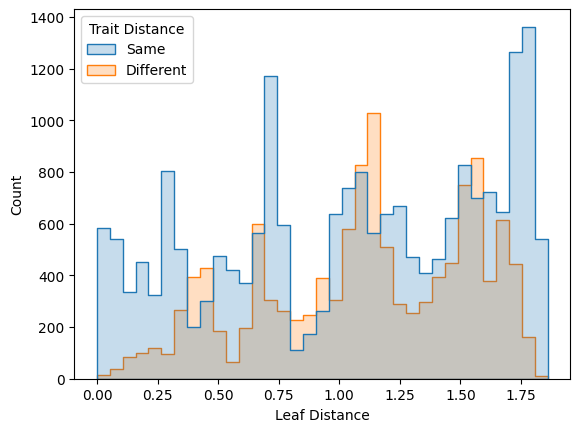

In [19]:
sns.histplot(data=leafdist_traitdist_data, x="Leaf Distance", hue="Trait Distance", element="step", stat="count")

## Calculate the phenotype-phylogeny correlation length using chi2 test

Contingency table:

| - | Same trait | Different trait |
| --- | --- | --- |
| Within threshold | a | b |
| Outside threshold | c | d |

In [20]:
from scipy.stats import chi2_contingency

In [21]:
def calculate_chi2(data):
    dataset_name = data["dataset_name"]
    phenotype_name = data["phenotype_name"]
    leafdist_traitdist_data = data["leafdist_traitdist_data"]
    distance_threshold = data["distance_threshold"]
    # within threshold
    within_thres = leafdist_traitdist_data["Leaf Distance"] < distance_threshold
    wt_sametrait = (leafdist_traitdist_data.loc[within_thres, "Trait Distance"] == "Same").sum()
    wt_difftrait = (leafdist_traitdist_data.loc[within_thres, "Trait Distance"] == "Different").sum()
    # outside threshold
    outside_thres = leafdist_traitdist_data["Leaf Distance"] >= distance_threshold
    ot_sametrait = (leafdist_traitdist_data.loc[outside_thres, "Trait Distance"] == "Same").sum()
    ot_difftrait = (leafdist_traitdist_data.loc[outside_thres, "Trait Distance"] == "Different").sum()
    # contingency_table = np.array([[wt_sametrait, wt_difftrait], [ot_sametrait, ot_difftrait]])
    contingency_table = np.array([[wt_sametrait, ot_sametrait], [wt_difftrait, ot_difftrait]])
    try:
        chisq, pvalue, dof, expected = chi2_contingency(contingency_table)
    except:
        chisq, pvalue = np.nan, np.nan
    return (dataset_name, phenotype_name, distance_threshold, chisq, pvalue)

In [22]:
min_leafdist = min(dataset_leafdist_dict[d][p].min().min() for d in dataset_leafdist_dict for p in dataset_leafdist_dict[d])
max_leafdist = min(dataset_leafdist_dict[d][p].max().max() for d in dataset_leafdist_dict for p in dataset_leafdist_dict[d])
min_leafdist, max_leafdist

(0.0, 0.5314099999999999)

In [23]:
corr_tasks = []
for dataset_name in dataset_tree_dict:
    for phenotype_name in dataset_tree_dict[dataset_name]:
        leafdist = dataset_leafdist_dict[dataset_name][phenotype_name]
        traitdist = dataset_traitdist_dict[dataset_name][phenotype_name]
        leafdist_traitdist_data = create_leafdist_traitdist_data(leafdist, traitdist)
        min_dist = leafdist_traitdist_data["Leaf Distance"].min()
        max_dist = leafdist_traitdist_data["Leaf Distance"].max()
        for distance_threshold in np.linspace(0, 2, 1000):
            data_item = {
                "leafdist_traitdist_data": leafdist_traitdist_data,
                "dataset_name": dataset_name,
                "phenotype_name": phenotype_name,
                "distance_threshold": distance_threshold
            }
            corr_tasks.append(data_item)

In [24]:
results = []
tasks_subset = corr_tasks
with mp.Pool(mp.cpu_count()) as pool:
    for result in tqdm(pool.imap(calculate_chi2, tasks_subset), total=len(tasks_subset)):
        results.append(result)

100%|██████████| 279000/279000 [08:26<00:00, 550.46it/s] 


In [25]:
results_df = pd.DataFrame(results, columns=["dataset_name", "phenotype_name", "distance_threshold", "chisq", "pvalue"])
results_df

,dataset_name,phenotype_name,distance_threshold,chisq,pvalue
0,atleaf,Xylose,0.000000,NaN,NaN
1,atleaf,Xylose,0.002002,179.114125,7.565633e-41
2,atleaf,Xylose,0.004004,217.524246,3.136334e-49
3,atleaf,Xylose,0.006006,239.983318,3.965911e-54
4,atleaf,Xylose,0.008008,252.834703,6.258389e-57
...,...,...,...,...,...
278995,pmi,Sucrose,1.991992,NaN,NaN
278996,pmi,Sucrose,1.993994,NaN,NaN
278997,pmi,Sucrose,1.995996,NaN,NaN
278998,pmi,Sucrose,1.997998,NaN,NaN


In [26]:
results_df[(results_df.dataset_name == "pmi") & (results_df.phenotype_name == "Acetate")].sort_values("pvalue", ascending=False)

,dataset_name,phenotype_name,distance_threshold,chisq,pvalue


Assuming a pvalue cutoff of 0.05, the correlation length is the distance at which the pvalue is greater than 0.05.

In [27]:
corrlen_df = results_df.groupby(by=["dataset_name", "phenotype_name"]).apply(lambda x: x[x["pvalue"] > 0.05].sort_values(by="distance_threshold").head(1), include_groups=False).reset_index().drop(columns="level_2")
corrlen_df

,dataset_name,phenotype_name,distance_threshold,chisq,pvalue
0,atleaf,Acetate,1.831832,3.370244,0.066384
1,atleaf,Alanine,1.071071,3.738365,0.053176
2,atleaf,Arabinose,0.522523,2.775908,0.095692
3,atleaf,Arginine,1.111111,3.424662,0.064229
4,atleaf,Asparagine,1.171171,2.413208,0.120316
...,...,...,...,...,...
244,pmi,d-Amino-Valeric-Acid,0.526527,2.221936,0.136062
245,pmi,m-Hydroxy-Phenylacetic-Acid,0.006006,3.165895,0.075191
246,pmi,m-Inositol,0.020020,1.064801,0.302123
247,pmi,m-Tartaric-Acid,0.506507,3.058379,0.080322


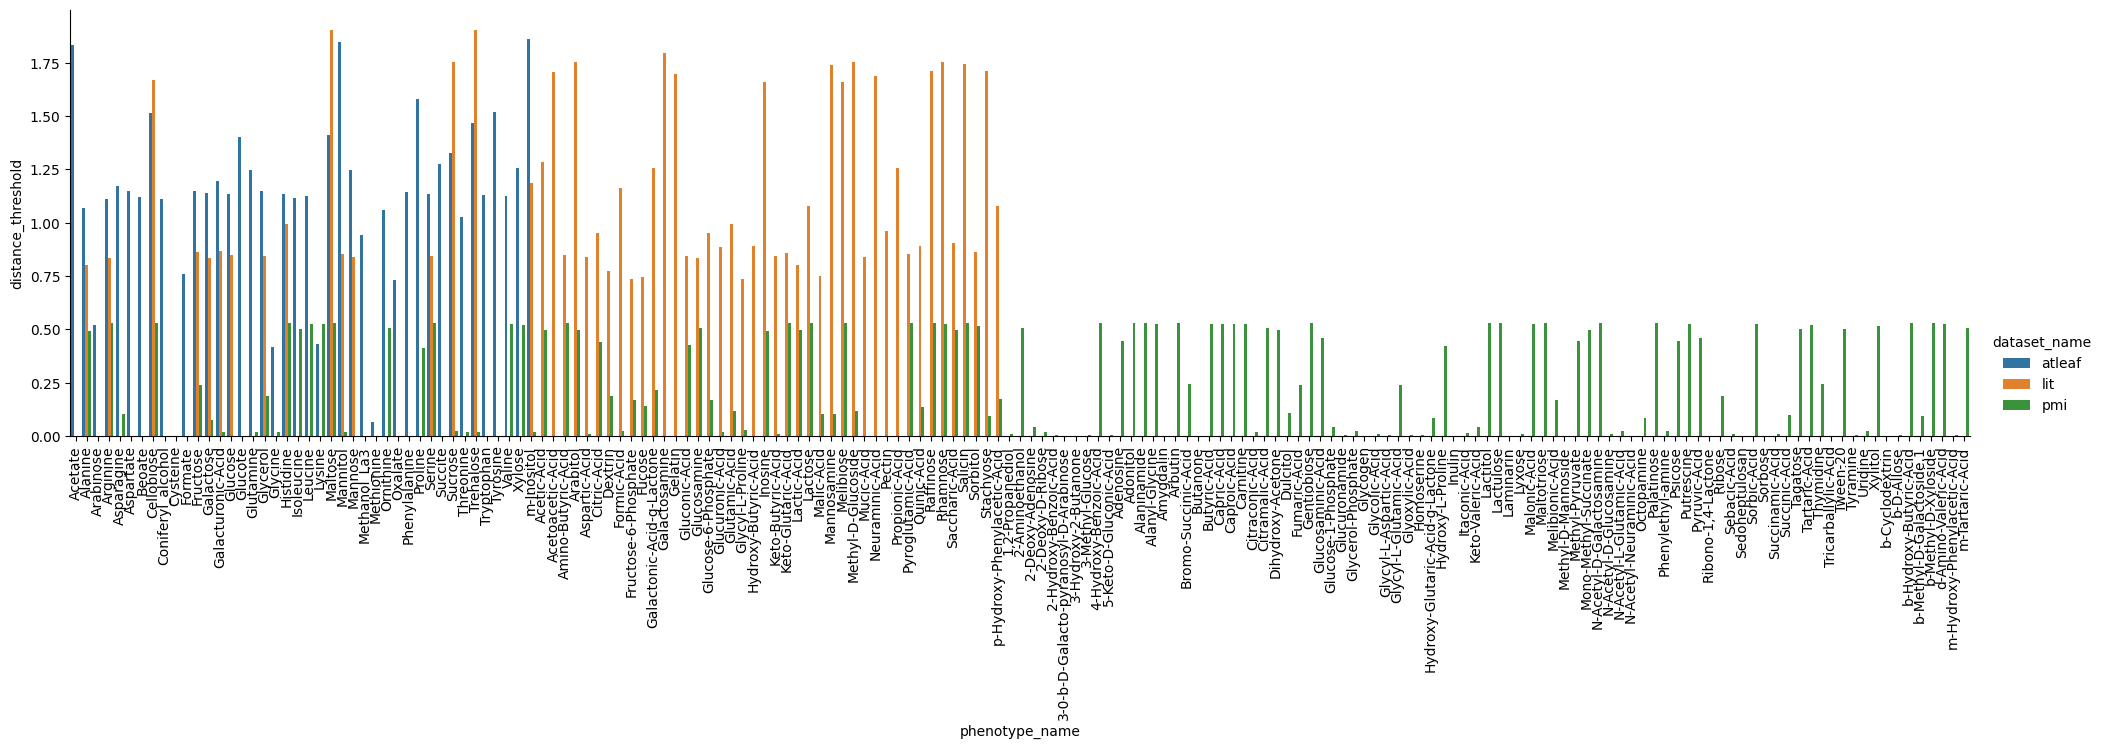

In [28]:
g = sns.catplot(data=corrlen_df, x="phenotype_name", y="distance_threshold", hue="dataset_name", kind="bar", aspect=4)
# Rotate x-axis labels by 90 degrees
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


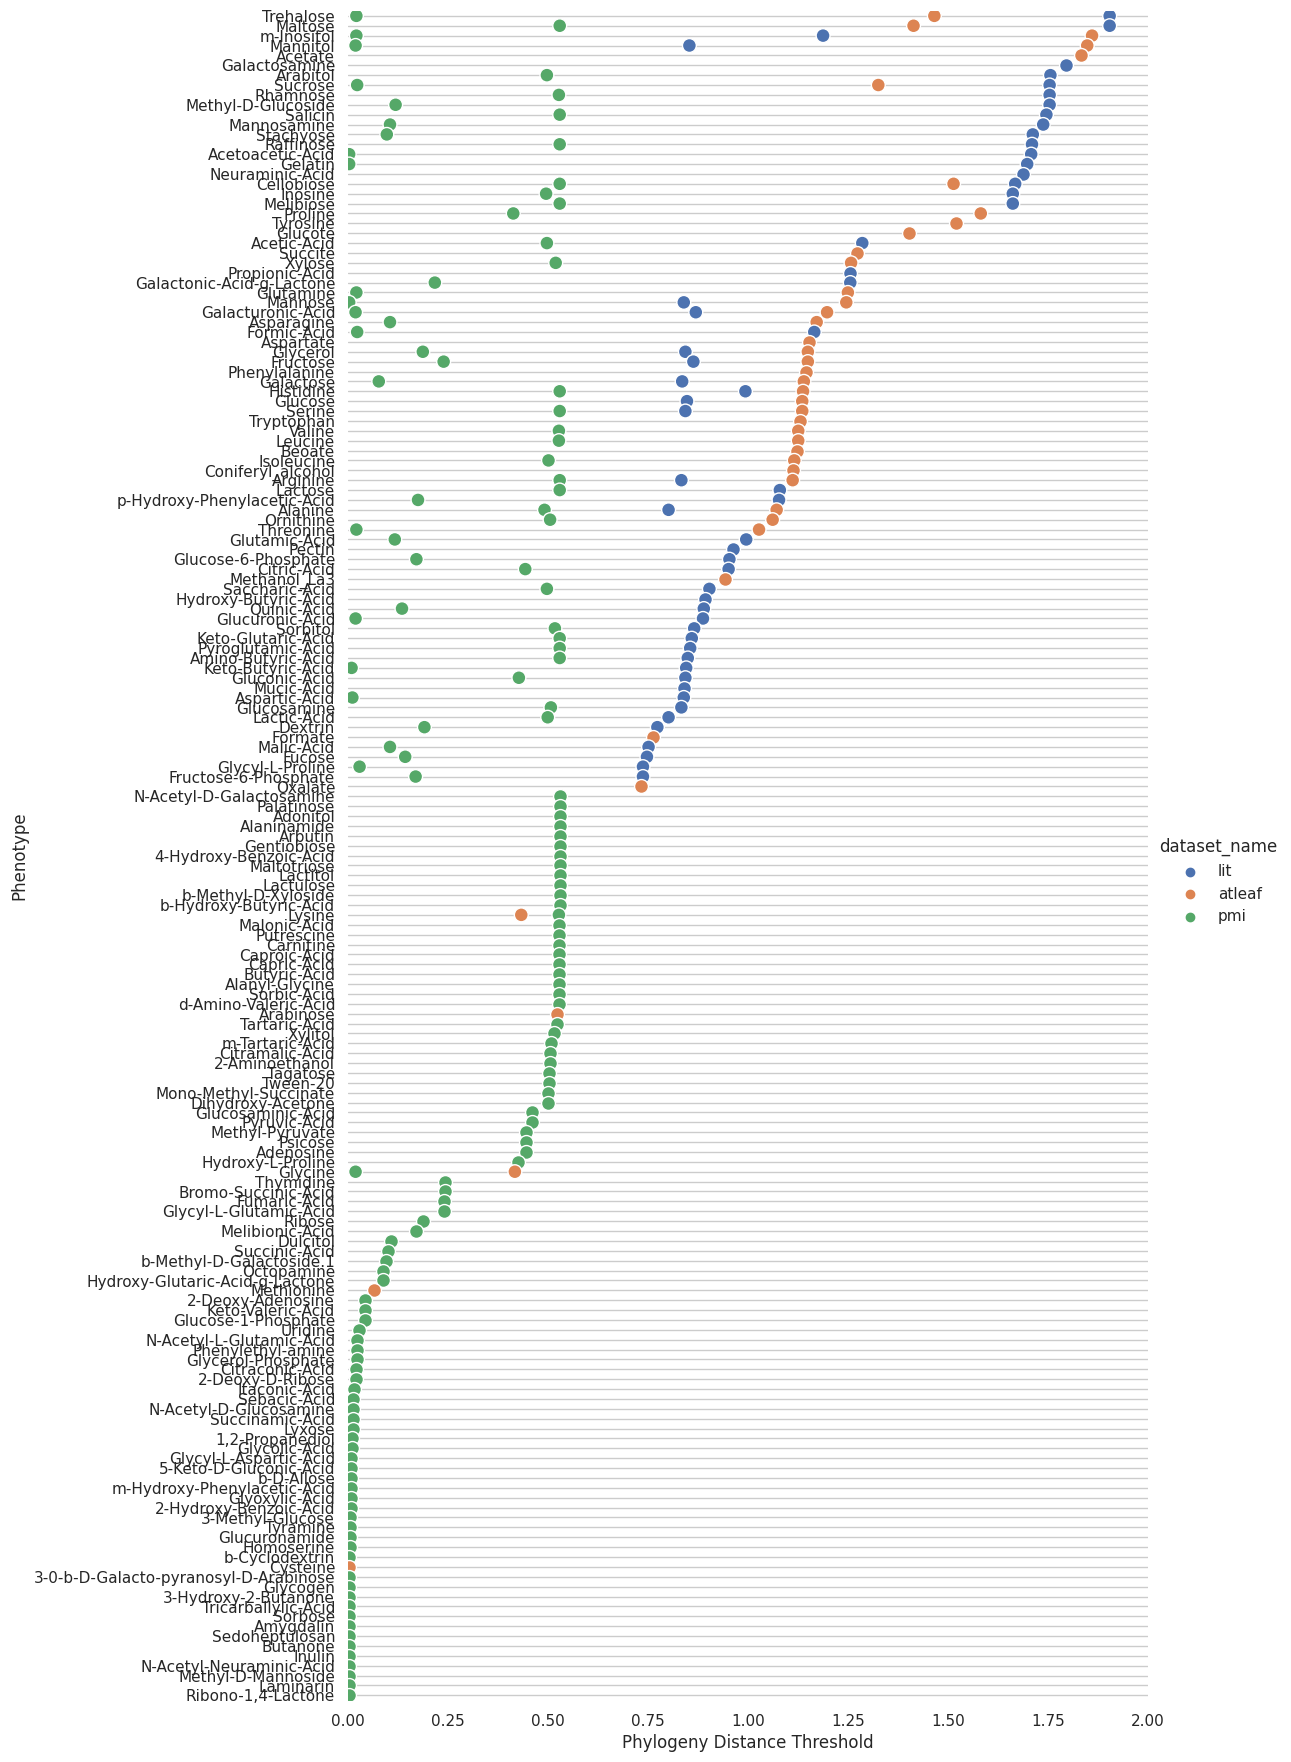

In [29]:
sns.set_theme(style="whitegrid")
g = sns.PairGrid(data=corrlen_df.sort_values(by="distance_threshold", ascending=False), hue="dataset_name",
                 x_vars=["distance_threshold"], y_vars=["phenotype_name"], height=18, aspect=0.5)
g.map(sns.stripplot, size=10, orient="h", jitter=False, palette="viridis_r", linewidth=1, edgecolor="w")
g.set(xlim=(0, 2), xlabel="Phylogeny Distance Threshold", ylabel="Phenotype")
for ax in g.axes.flat:
    ax.xaxis.grid(False)
    ax.yaxis.grid(True)
sns.despine(left=True, bottom=True)
# show legend
g.add_legend()

## Calculate phenotype-phylogeny correlation length using entropy and purity

In [9]:
from collections import defaultdict

from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd
from scipy.stats import entropy

In [10]:
def calculate_distance_matrix(tree):
    leaves = tree.get_leaf_names()
    distance_matrix = np.zeros((len(leaves), len(leaves)))
    for i, leaf1 in enumerate(leaves):
        for j, leaf2 in enumerate(leaves):
            if leaf1 == leaf2:
                distance_matrix[i, j] = 0
                continue
            distance = tree.get_distance(leaf1, leaf2)
            distance_matrix[i, j] = distance
    return distance_matrix

In [11]:
def get_clusters(distances, phenotype, distance_threshold):
    clustering = AgglomerativeClustering(linkage="single", distance_threshold=distance_threshold, n_clusters=None)
    labels = clustering.fit_predict(distances)
    cluster_dict = defaultdict(list)
    phenotype_map = phenotype.phenotype_data.to_dict()
    for leaf, label in zip(distances.index, labels):
        phenotype_value = phenotype_map[leaf]
        cluster_dict[label].append(phenotype_value)
    return cluster_dict

In [12]:
def calculate_entropy(data):
    tree = data["tree"]
    phenotype = data["phenotype"]
    dataset_name = data["dataset_name"]
    phenotype_name = data["phenotype_name"]
    distance_threshold = data["distance_threshold"]
    # Get distance matrix
    distance_matrix = calculate_distance_matrix(tree)
    distances = pd.DataFrame(distance_matrix, index=tree.get_leaf_names(), columns=tree.get_leaf_names())
    # Perform clustering
    phenotype_clusters = get_clusters(distances, phenotype, distance_threshold)
    # Calculate entropy
    entropy_dict = {}
    prob_dict = {}
    for cluster_id in phenotype_clusters:
        phenotype_values = phenotype_clusters[cluster_id]
        value_counts = np.bincount(phenotype_values)
        probs = value_counts / len(phenotype_values)
        prob_dict[cluster_id] = probs
        entropy_dict[cluster_id] = entropy(probs)
    entropy_val = np.mean(list(entropy_dict.values()))
    n_clusters = len(entropy_dict)
    # count fraction of clusters which have only one phenotype
    prob_val = np.mean([1 if np.isclose(prob, [1.0]).all() or np.isclose(prob, [0.0, 1.0]).all() else 0 for prob in prob_dict.values()])
    return (dataset_name, phenotype_name, distance_threshold, n_clusters, entropy_val, prob_val)

In [13]:
import multiprocessing as mp

In [14]:
tasks = []
for dataset_name in dataset_tree_dict:
    for phenotype_name in dataset_tree_dict[dataset_name]:
        tree = dataset_tree_dict[dataset_name][phenotype_name]
        phenotype = dataset_phenotype_dict[dataset_name][phenotype_name]
        for distance_threshold in np.linspace(0, 1, 20):
            data_item = {
                "tree": tree,
                "phenotype": phenotype,
                "dataset_name": dataset_name,
                "phenotype_name": phenotype_name,
                "distance_threshold": distance_threshold
            }
            tasks.append(data_item)

In [15]:
from tqdm import tqdm

In [16]:
results = []
tasks_subset = tasks
with mp.Pool(12) as pool:
    for result in tqdm(pool.imap(calculate_entropy, tasks_subset), total=len(tasks)):
        results.append(result)

100%|██████████| 5580/5580 [17:27<00:00,  5.33it/s]  


## Analyze the results

In [17]:
results_df = pd.DataFrame(results, columns=["dataset_name", "phenotype_name", "distance_threshold", "n_clusters", "entropy", "purity"])
results_df

,dataset_name,phenotype_name,distance_threshold,n_clusters,entropy,purity
0,atleaf,Xylose,0.000000,180,0.000000,1.000000
1,atleaf,Xylose,0.052632,115,0.011562,0.982609
2,atleaf,Xylose,0.105263,99,0.012682,0.979798
3,atleaf,Xylose,0.157895,84,0.035850,0.940476
4,atleaf,Xylose,0.210526,72,0.051695,0.916667
...,...,...,...,...,...,...
5575,pmi,Sucrose,0.789474,2,0.568246,0.000000
5576,pmi,Sucrose,0.842105,2,0.568246,0.000000
5577,pmi,Sucrose,0.894737,2,0.568246,0.000000
5578,pmi,Sucrose,0.947368,2,0.568246,0.000000


Assuming a cutoff of 0.9 purity, we calculate the correlation length for each phenotype and then analyze the results.

In [28]:
# for each dataset and phenotype we determine the distance_treshold that results in a purity of 0.9
corrlen_df = results_df.groupby(by=["dataset_name", "phenotype_name"]).apply(lambda x: x[x["purity"] > 0.9].sort_values(by="purity").head(1), include_groups=False).reset_index().drop(columns="level_2")
corrlen_df

,dataset_name,phenotype_name,distance_threshold,n_clusters,entropy,purity
0,atleaf,Acetate,0.157895,80,0.045042,0.925000
1,atleaf,Alanine,0.210526,74,0.055285,0.905405
2,atleaf,Arabinose,0.210526,73,0.040432,0.931507
3,atleaf,Arginine,0.263158,63,0.054514,0.904762
4,atleaf,Asparagine,0.052632,113,0.046865,0.929204
...,...,...,...,...,...,...
274,pmi,i-Erythritol,0.000000,55,0.000000,1.000000
275,pmi,m-Hydroxy-Phenylacetic-Acid,0.000000,55,0.000000,1.000000
276,pmi,m-Inositol,0.000000,55,0.000000,1.000000
277,pmi,m-Tartaric-Acid,0.000000,55,0.000000,1.000000


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

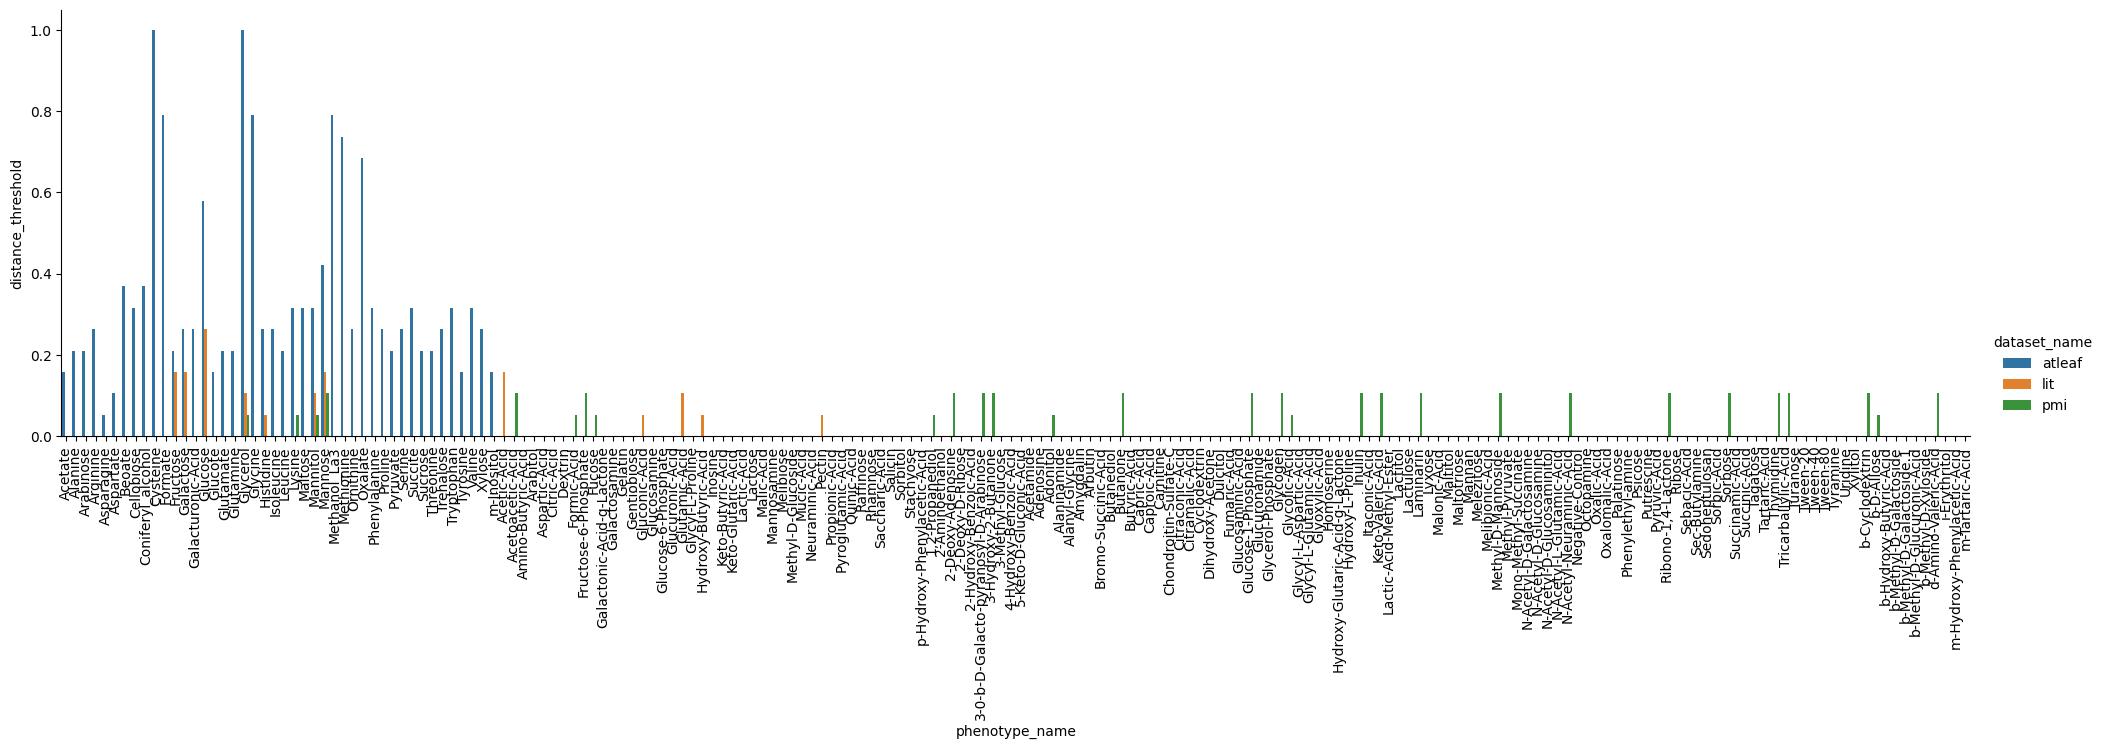

In [52]:
g = sns.catplot(data=corrlen_df, x="phenotype_name", y="distance_threshold", hue="dataset_name", kind="bar", aspect=4)
# Rotate x-axis labels by 90 degrees
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

In [43]:
def calculate_entropy_for_input(dataset_name, tree_dict, phenotype_name, phenotype_dict, distance_threshold):
    data_item = {
        "tree": tree_dict[dataset_name][phenotype_name],
        "phenotype": phenotype_dict[dataset_name][phenotype_name],
        "dataset_name": dataset_name,
        "phenotype_name": phenotype_name,
        "distance_threshold": distance_threshold
    }
    return calculate_entropy(data_item)

In [45]:
calculate_entropy_for_input("pmi", dataset_tree_dict, "Alanine", dataset_phenotype_dict, 0.0)

('pmi', 'Alanine', 0.0, 55, 0.0, 1.0)

In [47]:
len(dataset_tree_dict["pmi"]["Alanine"])

55

In [48]:
dataset_phenotype_dict["pmi"]["Alanine"].phenotype_data

genomeID
Bacillus_sp._BC15_2615840537                 0
Variovorax_sp._CF313_2513020051              0
Duganella_sp._CF402_2616644845               0
Pantoea_sp._YR343_2511231025                 1
Burkholderia_sp._BT03_2711768613             0
Rhizobium_sp._AP16_2510917022                1
Rhizobium_sp._CF394_2582581294               1
Rhizobium_sp._CF097_2582581866               1
Rhizobium_sp._CF122_2510917028               1
Rhizobium_sp._CF142_2510917030               0
Rhizobium_sp._CF258_2582581865               1
Rhizobium_sp._OK665_2582581283               0
Rhizobium_sp._OV201_2582581867               0
Rhizobium_leguminosarum_OV483_2582581299     0
Rhizobium_sp._YR295_2582581306               0
Rhizobium_sp._CF048_2585427590               1
Rhizobium_sp._CF080_2562617114               0
Agrobacterium_rhizogenes_CF262_2585428125    1
Agrobacterium_rhizogenes_CF263_2585427609    0
Rhizobium_leguminosarum_CF307_2585427528     1
Agrobacterium_rhizogenes_OK036_2582581316    0
Rhiz